In [1]:
from tensorflow.keras.datasets import mnist

In [2]:
(X_train , y_train)  ,(X_test , y_test) = mnist.load_data()

In [5]:
X_train = X_train/255
X_test = X_test/255

In [33]:
import tensorflow as tf
from tensorflow.keras.layers import Dropout,Conv2DTranspose,MaxPool2D,Conv2D,BatchNormalization,UpSampling2D
from tensorflow.keras.models import Sequential

In [27]:
# encoder

encoder = Sequential(name = 'encoder')
encoder.add(Conv2D(filters=8 , kernel_size=(3,3) , strides=(1,1) , padding='same' , activation='relu' , input_shape = (28,28,1)))
encoder.add(MaxPool2D())
encoder.add(Conv2D(filters=16 , kernel_size=(3,3) , strides=(1,1) , padding='same' , activation='relu'))
encoder.add(MaxPool2D())
encoder.add(Conv2D(filters=32 , kernel_size=(3,3) , strides=(1,1) , padding='same' , activation='relu'))


# decoder_Conv2DTranspose

decoder_Conv2DTranspose = Sequential(name='decoder_Conv2DTranspose')
decoder_Conv2DTranspose.add(Conv2DTranspose(filters=16, kernel_size=(3,3)  ,strides=(2,2) , padding='same' , activation='relu'))
decoder_Conv2DTranspose.add(Conv2DTranspose(filters=8 , kernel_size=(3,3)  ,strides=(2,2) , padding='same' , activation='relu'))
# perivious layer activation is relu and it's values maybe was grater than 1. Because of that sigmiod taking values [0,1] then we have to normalized it.
decoder_Conv2DTranspose.add(BatchNormalization())
decoder_Conv2DTranspose.add(Conv2DTranspose(filters=1 , kernel_size=(3,3)  ,strides=(1,1) , padding='same' , activation='sigmoid'))

# auto encoder_Conv2DTranspose

auto_encoder_Conv2DTranspose = Sequential(name='auto_encoder_Conv2DTranspose')
auto_encoder_Conv2DTranspose.add(encoder)
auto_encoder_Conv2DTranspose.add(decoder_Conv2DTranspose)

d:\python-venv\keras2\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [28]:
encoder.summary()

Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_10 (Conv2D)              │ (None, 28, 28, 8)      │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 14, 14, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 14, 14, 16)     │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 7, 7, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 7, 7, 32)       │         4,640 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,888 (23.00 KB)

 Trainable params: 5,888 (23.00 KB)

 Non-trainable params: 0 (0.00 B)

In [29]:
decoder_Conv2DTranspose.summary()

Model: "decoder_Conv2DTranspose"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_transpose_7              │ (None, 14, 14, 16)     │         4,624 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_8              │ (None, 28, 28, 8)      │         1,160 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 28, 28, 8)      │            32 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_9              │ (None, 28, 28, 1)      │            73 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,889 (23.00 KB)

 Trainable params: 5,873 (22.94 KB)

 Non-trainable params: 16 (64.00 B)

In [30]:
auto_encoder_Conv2DTranspose.summary()

Model: "auto_encoder_Conv2DTranspose"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder (Sequential)            │ (None, 7, 7, 32)       │         5,888 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_Conv2DTranspose         │ (None, 28, 28, 1)      │         5,889 │
│ (Sequential)                    │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,777 (46.00 KB)

 Trainable params: 11,761 (45.94 KB)

 Non-trainable params: 16 (64.00 B)

In [31]:
opt = tf.keras.optimizers.Adam(0.001)
loss = tf.keras.losses.MeanSquaredError()

auto_encoder_Conv2DTranspose.compile(optimizer= opt , loss= loss)

In [ ]:
auto_encoder_Conv2DTranspose.fit(X_train , X_train  , validation_data= (X_test , X_test) , epochs=15 , batch_size=50 , verbose=2)

Epoch 1/15
1200/1200 - 34s - 29ms/step - loss: 0.0145 - val_loss: 0.0037
Epoch 2/15
1200/1200 - 37s - 31ms/step - loss: 0.0034 - val_loss: 0.0035
Epoch 3/15
1200/1200 - 20s - 17ms/step - loss: 0.0029 - val_loss: 0.0030
Epoch 4/15
1200/1200 - 37s - 31ms/step - loss: 0.0026 - val_loss: 0.0024
Epoch 5/15
1200/1200 - 29s - 24ms/step - loss: 0.0024 - val_loss: 0.0022
Epoch 6/15
1200/1200 - 39s - 33ms/step - loss: 0.0023 - val_loss: 0.0021
Epoch 7/15
1200/1200 - 12s - 10ms/step - loss: 0.0022 - val_loss: 0.0021
Epoch 8/15
1200/1200 - 10s - 8ms/step - loss: 0.0021 - val_loss: 0.0023
Epoch 9/15
1200/1200 - 11s - 9ms/step - loss: 0.0020 - val_loss: 0.0020
Epoch 10/15
1200/1200 - 9s - 7ms/step - loss: 0.0020 - val_loss: 0.0019
Epoch 11/15
1200/1200 - 9s - 8ms/step - loss: 0.0019 - val_loss: 0.0019
Epoch 12/15
1200/1200 - 8s - 7ms/step - loss: 0.0019 - val_loss: 0.0018
Epoch 13/15
1200/1200 - 9s - 7ms/step - loss: 0.0018 - val_loss: 0.0018
Epoch 14/15
1200/1200 - 9s - 8ms/step - loss: 0.0018 - va

In [ ]:
X_pred_Conv2DTranspose = auto_encoder_Conv2DTranspose(X_train)

In [25]:
import matplotlib.pyplot as plt
import numpy as np

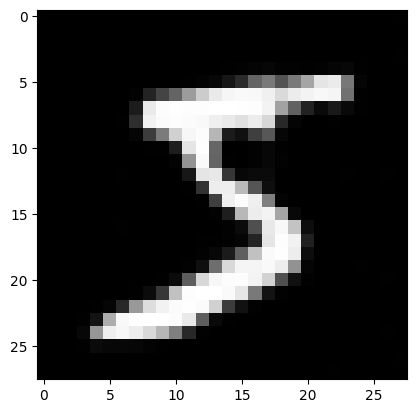

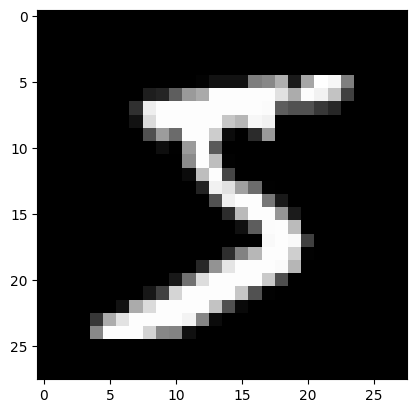

In [ ]:
plt.imshow(np.reshape(X_pred_Conv2DTranspose[0],(28,28)) , cmap='gray')
plt.show()
plt.imshow(np.reshape(X_train[0],(28,28)) , cmap='gray')
plt.show()

Now doing the same work with UpSampling2D.

In [35]:
# encoder

encoder = Sequential(name = 'encoder')
encoder.add(Conv2D(filters=8 , kernel_size=(3,3) , strides=(1,1) , padding='same' , activation='relu' , input_shape = (28,28,1)))
encoder.add(MaxPool2D())
encoder.add(Conv2D(filters=16 , kernel_size=(3,3) , strides=(1,1) , padding='same' , activation='relu'))
encoder.add(MaxPool2D())
encoder.add(Conv2D(filters=32 , kernel_size=(3,3) , strides=(1,1) , padding='same' , activation='relu'))


# decoder_UpSampling

decoder_UpSampling = Sequential(name='decoder_UpSampling')
decoder_UpSampling.add(UpSampling2D(size=(2,2)))
decoder_UpSampling.add(Conv2D(filters=16 , kernel_size=(3,3) , strides=(1,1) , padding='same' , activation='relu'))
decoder_UpSampling.add(UpSampling2D(size=(2,2)))
decoder_UpSampling.add(Conv2D(filters=8 , kernel_size=(3,3) , strides=(1,1) , padding='same' , activation='relu'))
# perivious layer activation is relu and it's values maybe was grater than 1. Because of that sigmiod taking values [0,1] then we have to normalized it.
decoder_UpSampling.add(BatchNormalization())
decoder_UpSampling.add(Conv2D(filters=1 , kernel_size=(2,2) , strides=(1,1) , padding='same' , activation='sigmoid'))


# auto encoder_UpSampling

auto_encoder_UpSampling = Sequential(name='auto_encoder_UpSampling')
auto_encoder_UpSampling.add(encoder)
auto_encoder_UpSampling.add(decoder_UpSampling)

In [36]:
encoder.summary()

Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_22 (Conv2D)              │ (None, 28, 28, 8)      │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 14, 14, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 14, 14, 16)     │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 7, 7, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_24 (Conv2D)              │ (None, 7, 7, 32)       │         4,640 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,888 (23.00 KB)

 Trainable params: 5,888 (23.00 KB)

 Non-trainable params: 0 (0.00 B)

In [37]:
decoder_UpSampling.summary()

Model: "decoder_UpSampling"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ up_sampling2d_2 (UpSampling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_25 (Conv2D)              │ (None, 14, 14, 16)     │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_3 (UpSampling2D)  │ (None, 28, 28, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_26 (Conv2D)              │ (None, 28, 28, 8)      │         1,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 8)      │            32 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_27 (Conv2D)              │ (None, 28, 28, 1)      │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,849 (22.85 KB)

 Trainable params: 5,833 (22.79 KB)

 Non-trainable params: 16 (64.00 B)

In [38]:
auto_encoder_UpSampling.summary()

Model: "auto_encoder_UpSampling"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder (Sequential)            │ (None, 7, 7, 32)       │         5,888 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_UpSampling (Sequential) │ (None, 28, 28, 1)      │         5,849 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,737 (45.85 KB)

 Trainable params: 11,721 (45.79 KB)

 Non-trainable params: 16 (64.00 B)

In [40]:
opt = tf.keras.optimizers.Adam(0.001)
loss = tf.keras.losses.MeanSquaredError()

auto_encoder_UpSampling.compile(optimizer= opt , loss= loss)

In [41]:
auto_encoder_UpSampling.fit(X_train , X_train  , validation_data= (X_test , X_test) , epochs=15 , batch_size=50 , verbose=2)

Epoch 1/15
1200/1200 - 32s - 27ms/step - loss: 0.0134 - val_loss: 0.0041
Epoch 2/15
1200/1200 - 35s - 29ms/step - loss: 0.0037 - val_loss: 0.0033
Epoch 3/15
1200/1200 - 15s - 13ms/step - loss: 0.0030 - val_loss: 0.0026
Epoch 4/15
1200/1200 - 14s - 11ms/step - loss: 0.0027 - val_loss: 0.0026
Epoch 5/15
1200/1200 - 17s - 14ms/step - loss: 0.0025 - val_loss: 0.0023
Epoch 6/15
1200/1200 - 33s - 27ms/step - loss: 0.0024 - val_loss: 0.0021
Epoch 7/15
1200/1200 - 67s - 56ms/step - loss: 0.0022 - val_loss: 0.0021
Epoch 8/15
1200/1200 - 67s - 56ms/step - loss: 0.0022 - val_loss: 0.0024
Epoch 9/15
1200/1200 - 71s - 59ms/step - loss: 0.0021 - val_loss: 0.0021
Epoch 10/15
1200/1200 - 96s - 80ms/step - loss: 0.0020 - val_loss: 0.0020
Epoch 11/15
1200/1200 - 141s - 117ms/step - loss: 0.0020 - val_loss: 0.0021
Epoch 12/15
1200/1200 - 143s - 119ms/step - loss: 0.0019 - val_loss: 0.0018
Epoch 13/15
1200/1200 - 145s - 121ms/step - loss: 0.0019 - val_loss: 0.0018
Epoch 14/15
1200/1200 - 81s - 67ms/step -

In [42]:
X_pred_UpSampling = auto_encoder_UpSampling(X_train)

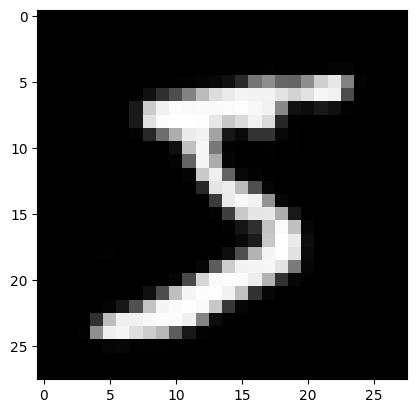

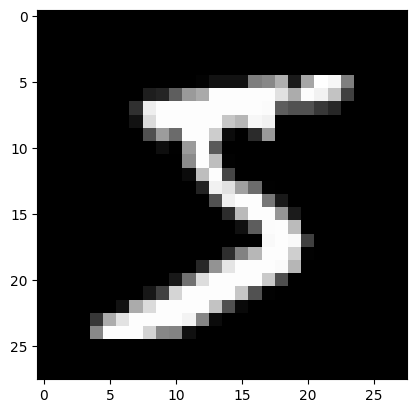

In [43]:
plt.imshow(np.reshape(X_pred_UpSampling[0],(28,28)) , cmap='gray')
plt.show()
plt.imshow(np.reshape(X_train[0],(28,28)) , cmap='gray')
plt.show()